In [ ]:
# NETFLIX MOVIE ANALYSIS

## Step 1: Data Acquisition and Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
df = pd.read_csv('netflix_titles.csv')

# Initial Inspection
print('First 5 rows:')
print(df.head())
print('Shape of the dataset:')
print(df.shape)
print('Data types and non-null counts:')
df.info()
print('Summary of numerical columns:')
print(df.describe())

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

In [ ]:
## Step 2: Data Cleaning and Preprocessing

In [3]:
# Identify missing values
print('Missing values per column:')
print(df.isnull().sum())

# For this dataset, let's assume we drop rows with any missing values for simplicity
df.dropna(inplace=True)

# Data Type Correction (if necessary) - example
# df['some_column'] = pd.to_numeric(df['some_column'], errors='coerce')

print('Shape after dropping missing values:')
print(df.shape)

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Shape after dropping missing values:
(5332, 12)


In [4]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')


In [ ]:
## Step 3: Exploratory Data Visualization

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51105 (\N{HANGUL SYLLABLE JAB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/sit

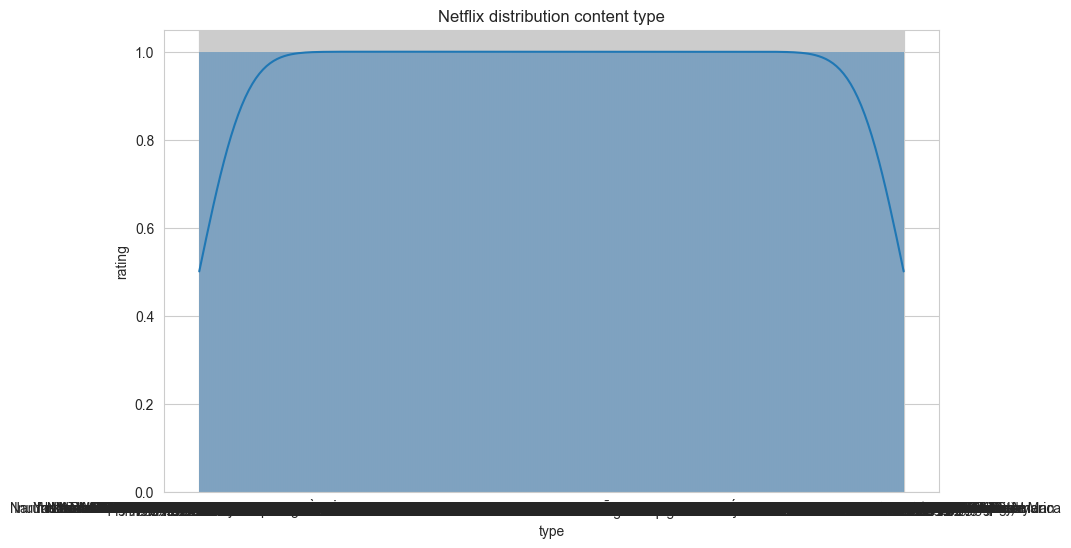

In [19]:
sns.set_style('whitegrid')

# Univariate Analysis: Histogram for Content Type
plt.figure(figsize=(10, 6))
sns.histplot(df['title'], kde=True, bins=30)
plt.title('Netflix distribution content type')
plt.xlabel('type')
plt.ylabel('rating')
plt.show()

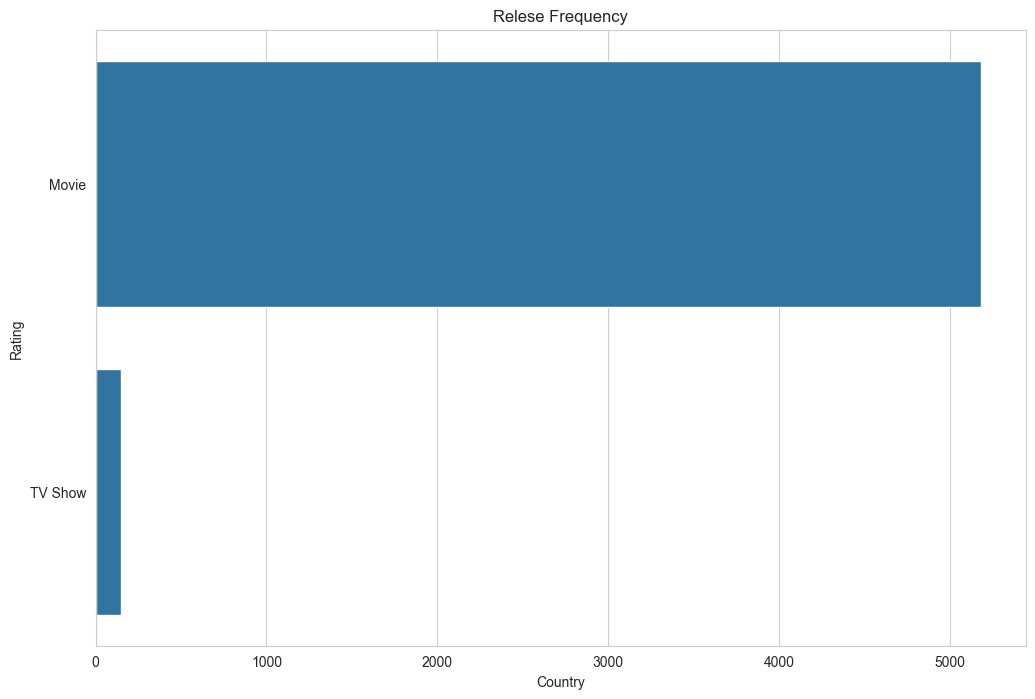

In [ ]:
# Univariate Analysis: Bar Plot for Release Trends
plt.figure(figsize=(12, 8))
sns.countplot(y='type', data=df, order = df['type'].value_counts().index)
plt.title('Relese Frequency')
plt.xlabel('Country')
plt.ylabel('Type')
plt.show()

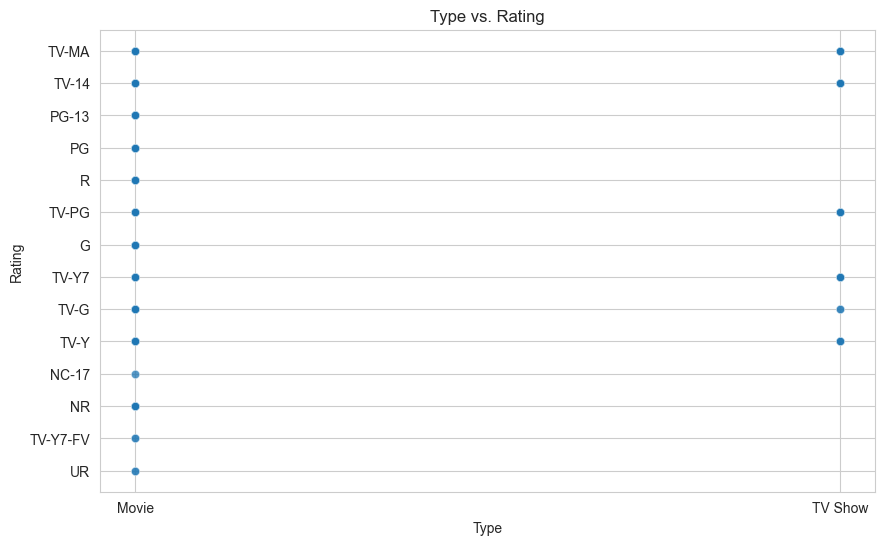

In [24]:
# Bivariate Analysis: Scatter Plot for Type vs. Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='type', y='rating', data=df, alpha=0.5)
plt.title('Type vs. Rating')
plt.xlabel('Type')
plt.ylabel('Rating')
plt.show()

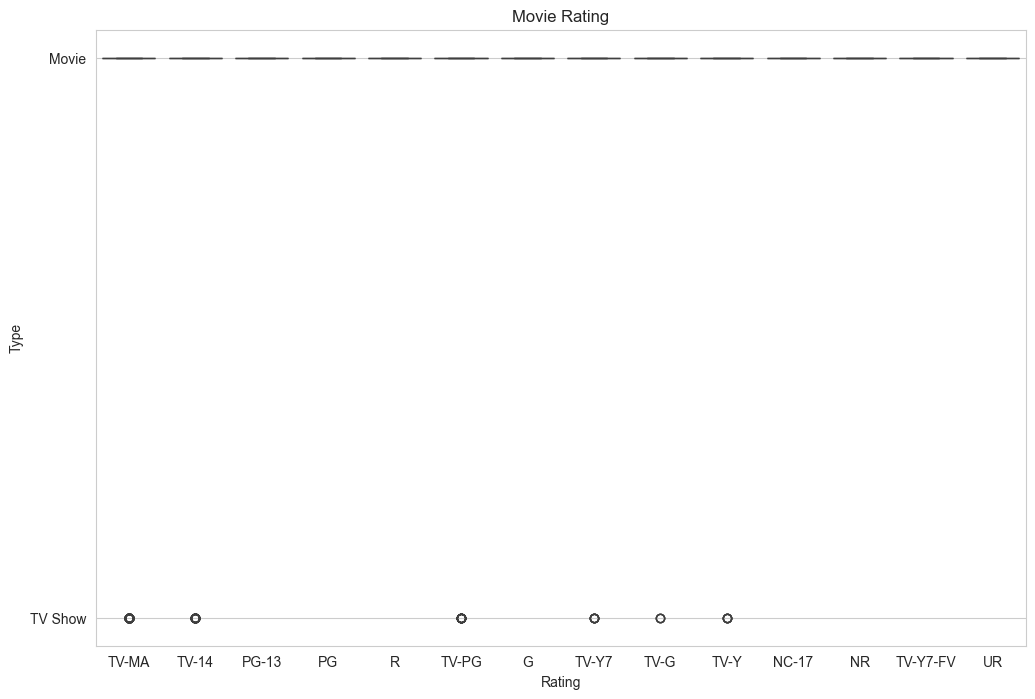

In [26]:
# Bivariate Analysis: Box Plot for Type by Rating
plt.figure(figsize=(12, 8))
sns.boxplot(y='type', x='rating', data=df)
plt.title('Movie Rating')
plt.xlabel('Rating')
plt.ylabel('Type')
plt.show()

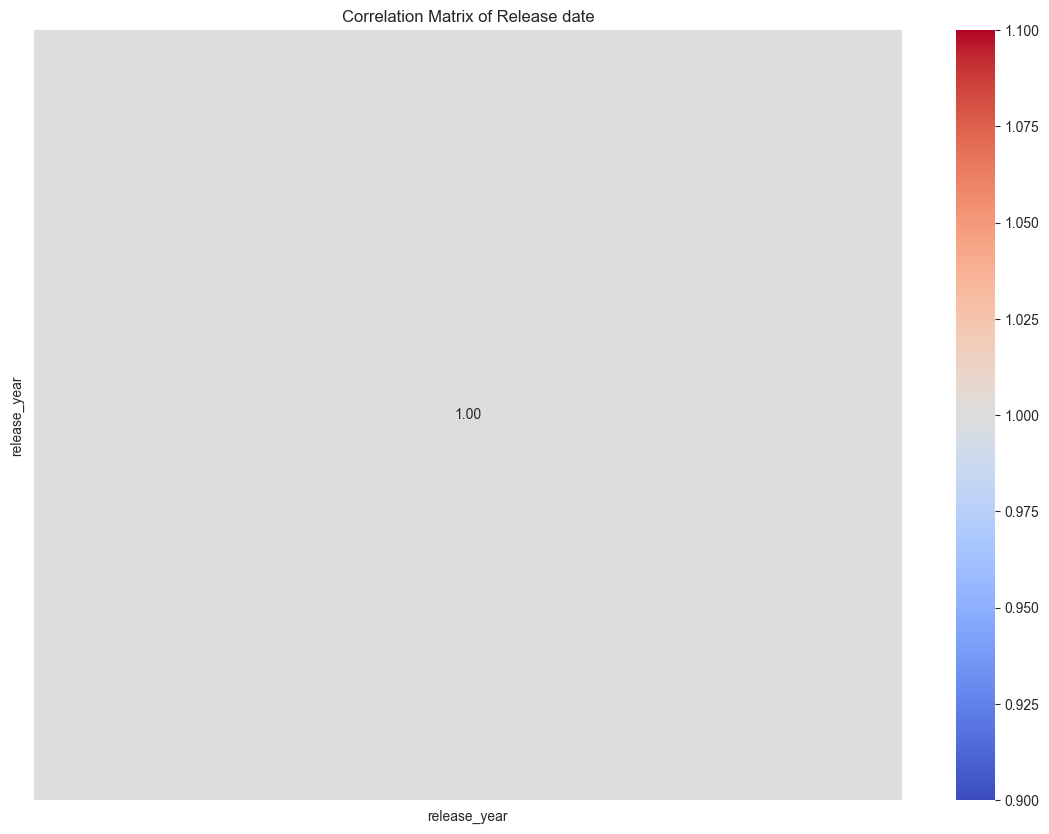

In [27]:
# Correlation Analysis: Heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Release date')
plt.show()